In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2
import os 

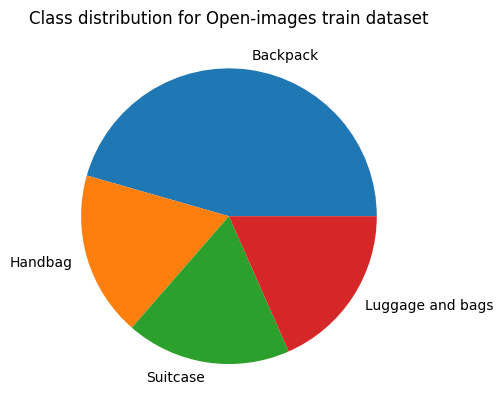

In [2]:
OI_label_dir = "../../data/raw_data/bag_detection_dataset/labels/train"
# print(os.listdir(OI_label_dir))
counter = {}
try:
    for file in os.listdir(OI_label_dir):
        if file.endswith(".txt"):
            #need to use os.path.join to access indiv .txt file,else permission issue
            with open(os.path.join(OI_label_dir,file),"r") as f:
                lines = f.readlines()
                for line in lines:
                    class_id = line.split()[0]
                    counter[class_id] = counter.get(class_id, 0) + 1
except Exception as e:
    print(f'Error with file processing:{e}')

chart_labels = {0: "Backpack",1:"Handbag",2:"Suitcase",3:"Luggage and bags"}
plt.pie(counter.values(),labels = chart_labels.values())
plt.title("Class distribution for Open-images train dataset")
plt.show()

Width statistics
Min: 498
Max: 3872
Average: 951.02125

Height statistics
Min: 401
Max: 2592
Average: 835.74625


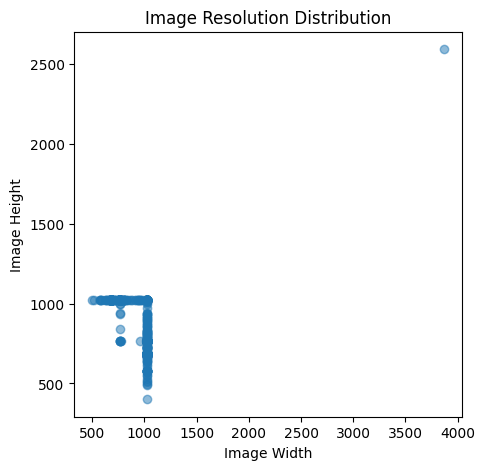

In [10]:
OI_image_dir = "../../data/raw_data/bag_detection_dataset/images/train"

widths = []
heights = []

try:
    for file in os.listdir(OI_image_dir):
        img_path = os.path.join(OI_image_dir,file)
        img = Image.open(img_path)
        w,h = img.size
        widths.append(w)
        heights.append(h)
except Exception as e:
    print(f'Error processing image: {e}')

plt.figure(figsize=(5,5))

plt.scatter(widths, heights, alpha=0.5)

plt.xlabel("Image Width")
plt.ylabel("Image Height")
plt.title("Image Resolution Distribution")

print("Width statistics")
print("Min:", min(widths))
print("Max:", max(widths))
print("Average:", sum(widths)/len(widths))

print("\nHeight statistics")
print("Min:", min(heights))
print("Max:", max(heights))
print("Average:", sum(heights)/len(heights))
plt.show()

Open-images dataset contains images with width, ranging from 498 to 3872 pixels, and height,range from 401 to 2592 pixels.

In [ ]:
#IMPT: DO NOT RUN THIS CELL, PC WILL BOOM 
# r_values = []
# g_values = []
# b_values = []

# for file in os.listdir(OI_image_dir):
#     img_path = os.path.join(OI_image_dir, file)
#     img = cv2.imread(img_path)

#     # split channels
#     b, g, r = cv2.split(img)

#     r_values.extend(r.flatten())
#     g_values.extend(g.flatten())
#     b_values.extend(b.flatten())

In [ ]:
# plt.figure(figsize=(8,6))

# plt.hist(r_values, bins=50, color='red', alpha=0.5, label='Red')
# plt.hist(g_values, bins=50, color='green', alpha=0.5, label='Green')
# plt.hist(b_values, bins=50, color='blue', alpha=0.5, label='Blue')

# plt.xlabel("Pixel Intensity (0–255)")
# plt.ylabel("Frequency")
# plt.title("RGB Pixel Value Distribution")

# plt.legend()
# plt.show()

## Merged dataset cleaning

This section will help with the initial cleaning of the dataset via the handling of corrupt or irrelevant images and labels.

It will delete the images/labels with its corresponding labels/images if the file is deemed invalid for analysis.

The Goal is to ensure that the train, test, validation sets are full of valid images and labels for analysis and modelling.

In [98]:
MERGED_DATASET_IMAGES_TRAIN_DIR = "../../final_unified_dataset/images/train"

MERGED_DATASET_LABELS_TRAIN_DIR = "../../final_unified_dataset/labels/train"

MERGED_DATASET_IMAGES_TEST_DIR = "../../final_unified_dataset/images/test"

MERGED_DATASET_LABELS_TEST_DIR = "../../final_unified_dataset/labels/test"

MERGED_DATASET_IMAGES_VAL_DIR = "../../final_unified_dataset/images/val"

MERGED_DATASET_LABELS_VAL_DIR = "../../final_unified_dataset/labels/val"

MERGED_DATASET_YAML = "../../final_unified_dataset/dataset.yaml"

In [99]:
# Checking of invalid images 
import os
import cv2
from PIL import Image
from pathlib import Path

# Allow the attempt of loading image files that are incomplete or corrupted instead of raising error


def check_image_integrity(image_folder):
    
    """
    Tests each file in the folder whether it is a valid image file
    
    1. Correct extension (JPG, JPEG, PNG, BMP, WEBP)
    
    2. Size Check (Cannot be 0 bytes)
    
    3. Check if the image is corrupted via Image.verify(), catches corruption in a try execpt block
    
    Returns a list of invalid images/files
    
    """
    
    
    invalid_images = []
    valid_extensions = ('.jpg', '.jpeg', '.png','.bmp','.webp')
    
    if "labels" in image_folder:
        print(f"Warning: The folder {image_folder} does not seem to be an image folder.")
        return invalid_images
    
    all_files = os.listdir(image_folder)

    
    
    print(f"Checking {len(all_files)} images...")
    
    for filename in all_files:
        path = os.path.join(image_folder, filename)
        
        ext = os.path.splitext(filename)[1].lower()
        
        # 1. Extension Check
        if ext not in valid_extensions:
            invalid_images.append((path, "invalid extension"))
            continue
        
        # 2. Check if file is 0 bytes
        if os.path.getsize(path) == 0:
            invalid_images.append((path, "0 bytes"))
            continue
            
        # 3. Try to open with OpenCV or PIL to check for corruption
        try:
            img = cv2.imread(path)
            if img is None:
                # Try PIL if CV2 fails (sometimes helps with metadata issues)
                with Image.open(path) as pil_img:
                    pil_img.verify()
            else:
                h, w, c = img.shape
                if h == 0 or w == 0:
                    invalid_images.append((path, "zero_dimension"))
        except Exception as e:
            invalid_images.append((path, "corrupted"))
            
    return invalid_images



# Removing of invalid images from specified folder


from pathlib import Path

def synchronized_file_removal(invalid_entries, image_dir, label_dir):
    """
    Deletes the invalid file AND its corresponding pair (image <-> label).
    invalid_entries: List of tuples (file_path_string, reason)
    """
    if not invalid_entries:
        print("No files to delete.")
        return

    img_dir = Path(image_dir)
    lbl_dir = Path(label_dir)

    for file_path_str, reason in invalid_entries:
        current_file = Path(file_path_str)
        
        # Safety Check: Never delete the class definition file
        if current_file.name == "classes.txt":
            continue

        base_name = current_file.stem  # Filename without extension
        
        # Define potential pairs
        # We check common image extensions in case the flagged file was a label
        possible_images = [img_dir / f"{base_name}{ext}" for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']]
        label_file = lbl_dir / f"{base_name}.txt"

        # --- 1. DELETE THE FLAGGED FILE ---
        if current_file.exists():
            try:
                current_file.unlink()
                print(f"🗑️ Deleted flagged file: {current_file.name} ({reason})")
            except OSError as e:
                print(f"❌ Error deleting {current_file.name}: {e}")

        # --- 2. DELETE THE SYNCED PARTNER ---
        # If an image was flagged, find and delete the label
        if current_file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:
            if label_file.exists():
                label_file.unlink()
                print(f"🔗 Cleaned up orphan label: {label_file.name}")

        # If a label was flagged, find and delete the image
        elif current_file.suffix.lower() == '.txt':
            for img_pair in possible_images:
                if img_pair.exists():
                    img_pair.unlink()
                    print(f"🔗 Cleaned up orphan image: {img_pair.name}")
                    break



In [101]:
# Checking train images

# Usage for train images, can be repeated for test and val images by changing the directory path in the function call
errors_train = check_image_integrity(MERGED_DATASET_IMAGES_TRAIN_DIR)
print(f"Found {len(errors_train)} invalid images.")
print(errors_train)

#Deletes the corrupt files
synchronized_file_removal(errors_train, MERGED_DATASET_IMAGES_TRAIN_DIR, MERGED_DATASET_LABELS_TRAIN_DIR)


Checking 2639 images...
Found 0 invalid images.
[]
No files to delete.


In [102]:
errors_test = check_image_integrity(MERGED_DATASET_IMAGES_TEST_DIR)
print(f"Found {len(errors_test)} invalid images.")
print(errors_test)

#Deletes the corrupt files
synchronized_file_removal(errors_test, MERGED_DATASET_IMAGES_TEST_DIR, MERGED_DATASET_LABELS_TEST_DIR)


Checking 375 images...
Found 0 invalid images.
[]
No files to delete.


In [103]:
errors_val = check_image_integrity(MERGED_DATASET_IMAGES_VAL_DIR)
print(f"Found {len(errors_val)} invalid images.")
print(errors_val)

#Deletes the corrupt files
synchronized_file_removal(errors_val, MERGED_DATASET_IMAGES_VAL_DIR, MERGED_DATASET_LABELS_VAL_DIR)

    

Checking 628 images...
Found 0 invalid images.
[]
No files to delete.


In [104]:
def validate_yolo_annotations(label_folder):
    issues = []
    all_files = os.listdir(label_folder)
    print(f"Checking {len(all_files)} labels...")
    for filename in os.listdir(label_folder):
        if filename.endswith(".txt"):
            file_path = os.path.join(label_folder, filename)
            
            # Check file size first - quick way to find empty files
            if os.path.getsize(file_path) == 0:
                issues.append((file_path, "Empty File"))
                continue

            with open(file_path, 'r') as f:
                lines = f.readlines()
                
                # Double check if it's just whitespace/empty lines
                if not any(line.strip() for line in lines):
                    issues.append((file_path, "Empty or whitespace only"))
                    continue

                for line in lines:
                    parts = line.split()
                    if len(parts) != 5:
                        issues.append((file_path, "Malformed line"))
                        continue
                    
                    try:
                        cls, x, y, w, h = map(float, parts)
                        if not all(0 <= val <= 1 for val in [x, y, w, h]):
                            issues.append((file_path, f"Out of bounds: {x, y, w, h}"))
                    except ValueError:
                        issues.append((file_path, "Non-numeric data detected"))
                        
    return issues

In [105]:
# Check train labels
train_label_issues = validate_yolo_annotations(MERGED_DATASET_LABELS_TRAIN_DIR)
print(f"Found {len(train_label_issues)} issues in train labels.")
print(train_label_issues)

synchronized_file_removal(train_label_issues, MERGED_DATASET_IMAGES_TRAIN_DIR, MERGED_DATASET_LABELS_TRAIN_DIR)


Checking 2639 labels...
Found 1 issues in train labels.
[('../../final_unified_dataset/labels/train\\3294_png.rf.0fa6faf39ed11fde9b4c0c3e9f1ef683.txt', 'Empty File')]
🗑️ Deleted flagged file: 3294_png.rf.0fa6faf39ed11fde9b4c0c3e9f1ef683.txt (Empty File)
🔗 Cleaned up orphan image: 3294_png.rf.0fa6faf39ed11fde9b4c0c3e9f1ef683.jpg


In [106]:
test_label_issues = validate_yolo_annotations(MERGED_DATASET_LABELS_TEST_DIR)
print(f"Found {len(test_label_issues)} issues in test labels.")
print(test_label_issues)

synchronized_file_removal(test_label_issues, MERGED_DATASET_IMAGES_TEST_DIR, MERGED_DATASET_LABELS_TEST_DIR)


Checking 375 labels...
Found 0 issues in test labels.
[]
No files to delete.


In [107]:
val_label_issues = validate_yolo_annotations(MERGED_DATASET_LABELS_VAL_DIR)
print(f"Found {len(val_label_issues)} issues in validation labels.")
print(val_label_issues)

synchronized_file_removal(val_label_issues, MERGED_DATASET_IMAGES_VAL_DIR, MERGED_DATASET_LABELS_VAL_DIR)


Checking 628 labels...
Found 0 issues in validation labels.
[]
No files to delete.


## Initial Exploratory Data Analysis

This section serves to explore the samples in the datasets, its distribution and provide analysis on its characteristics such as spatial resolution, similarities with other images.

In [108]:
# Showing samples from each class in the dataset to check for visual consistency and annotation quality

import os
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path

def plot_samples(image_dir, label_dir, num_samples=4, class_names=['Person', 'Bag']):
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png'))]
    
    # Randomly shuffle and pick samples
    random.shuffle(image_files)
    samples = image_files[:num_samples]
    
    # Calculate grid size (e.g., for 4 samples, a 2x2 grid looks better than a long line)
    cols = 2
    rows = (num_samples + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = axes.flatten()

    for i, img_name in enumerate(samples):
        img_path = os.path.join(image_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        # Consistent font and thickness based on image size
        font_scale = w / 1000
        thickness = max(1, int(w / 300))
        
        label_path = os.path.join(label_dir, Path(img_name).stem + ".txt")
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    cls_id, x, y, bw, bh = map(float, line.split())
                    
                    # YOLO to Pixel Coordinates
                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)
                    
                    # Pick color based on class (e.g., Red for Person, Blue for Bag)
                    color = (255, 0, 0) if int(cls_id) == 0 else (0, 255, 0)
                    
                    # Draw Bounding Box
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
                    
                    # Draw Text Background (so text is readable)
                    label_text = class_names[int(cls_id)]
                    (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
                    cv2.rectangle(img, (x1, y1 - th - 5), (x1 + tw, y1), color, -1)
                    cv2.putText(img, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 
                                font_scale, (255, 255, 255), max(1, thickness//2))
        
        axes[i].imshow(img)
        axes[i].set_title(f"Source: {img_name}\nRes: {w}x{h}", fontsize=12)
        axes[i].axis('off')

    # Clean up empty subplots if num_samples is odd
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# plot_samples('path/to/images', 'path/to/labels')

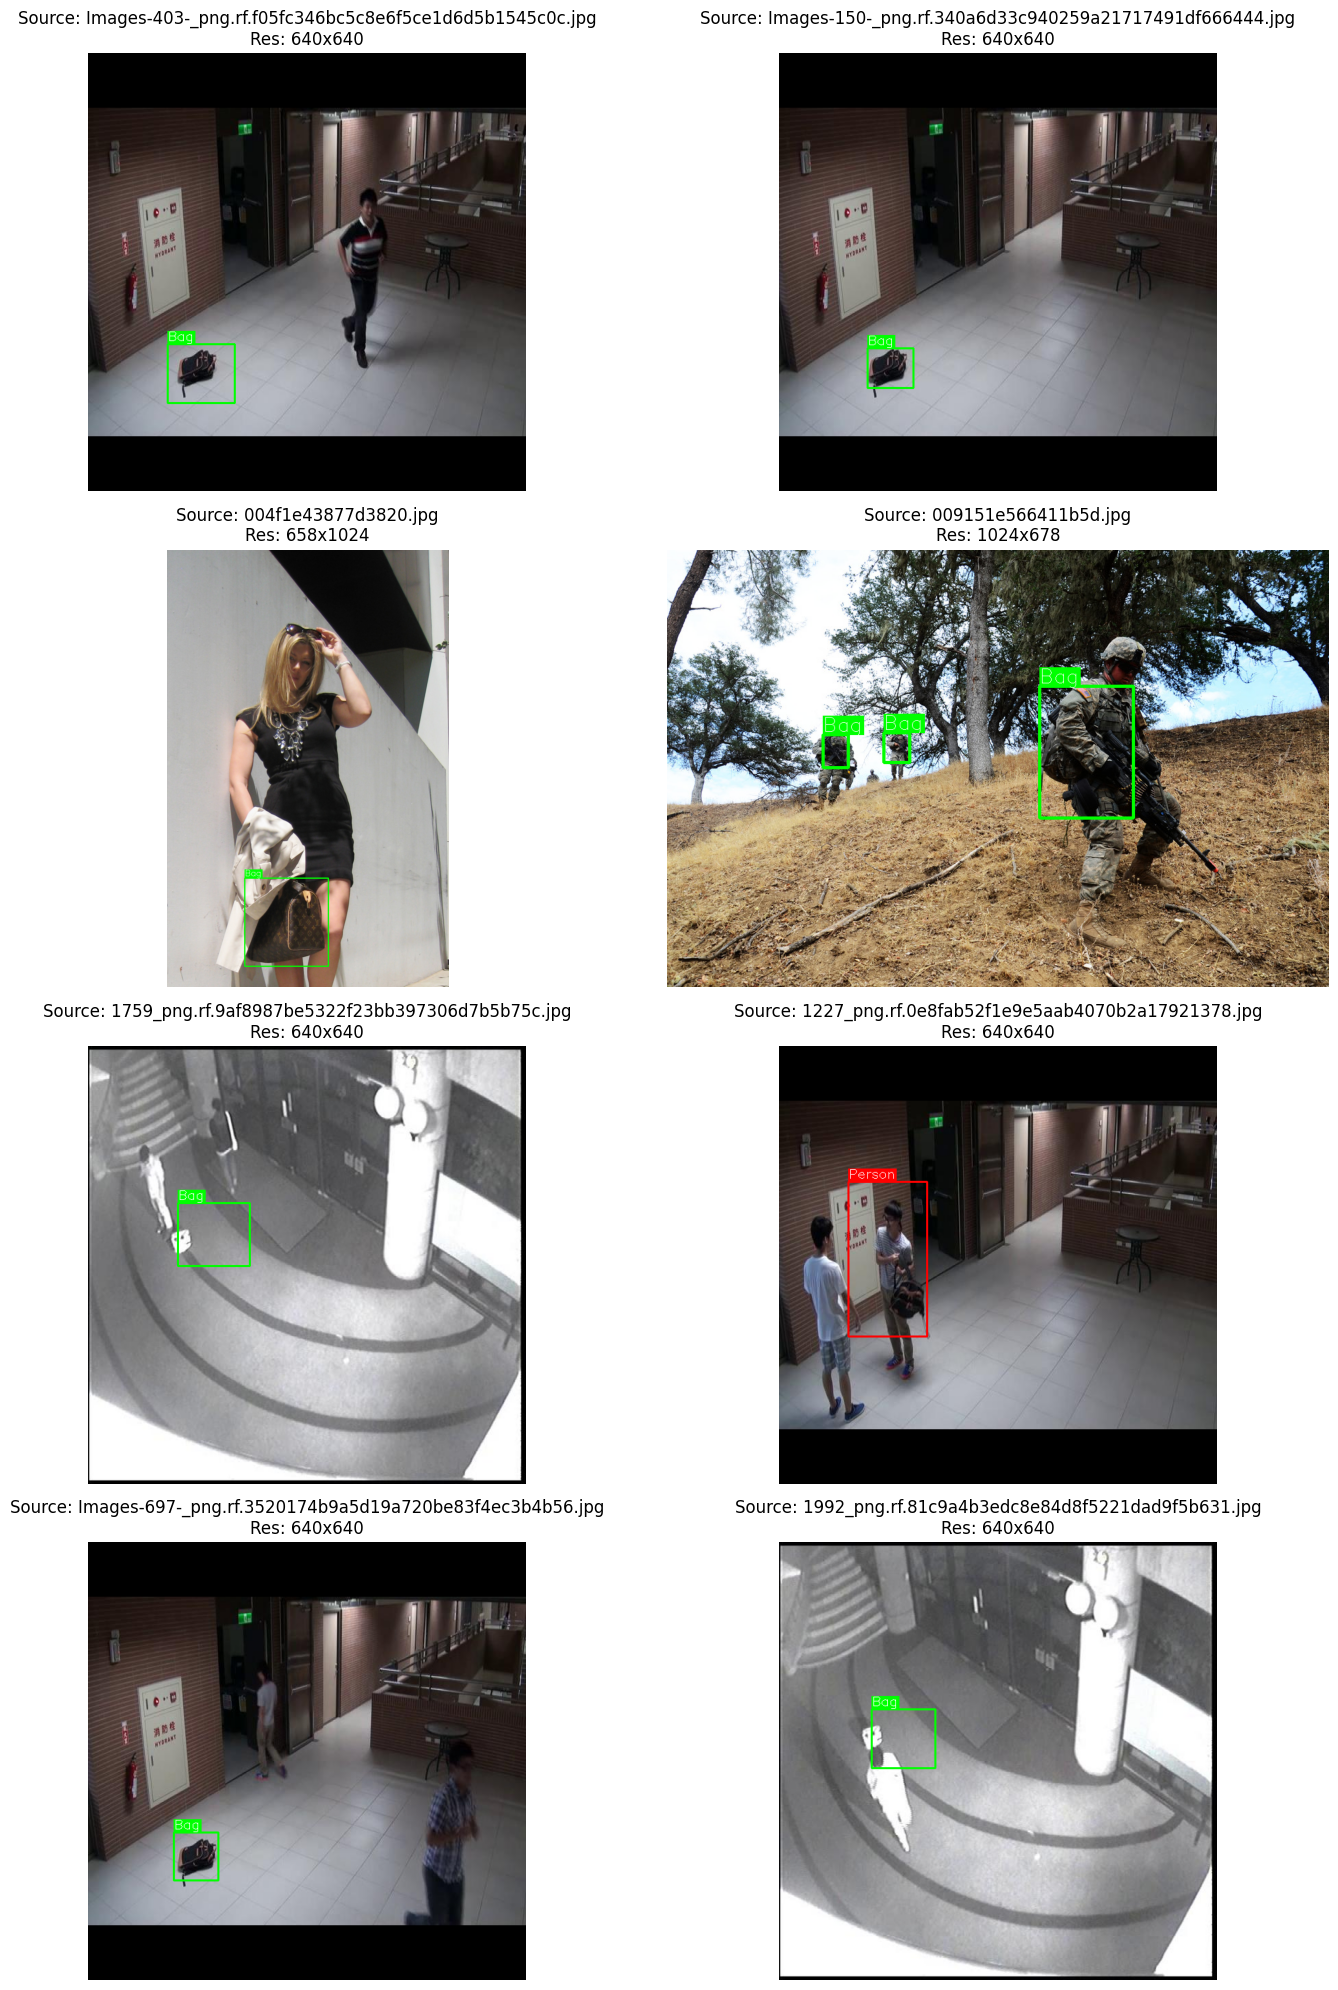

In [116]:
# Train samples
plot_samples(MERGED_DATASET_IMAGES_TRAIN_DIR, MERGED_DATASET_LABELS_TRAIN_DIR,num_samples=8)
